# JOUR 2 - MODÉLISATION ET OPTIMISATION

**Projet Fil Rouge - Prédiction de Churn Client**

**Objectifs du Jour 2**:
- Comparer au minimum 5 algorithmes différents
- Optimiser les hyperparamètres
- Gérer le déséquilibre des classes
- Atteindre Recall ≥ 75%

**Durée estimée**: 7 heures

## 0. SETUP ET CHARGEMENT DES DONNÉES

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             accuracy_score, precision_score, recall_score, f1_score,
                             average_precision_score)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

In [5]:
import joblib

# Charger les splits sauvegardés du Jour 1
X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled = joblib.load('/content/train_test_splits.pkl')

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.2%}")

Train: (5634, 50), Test: (1409, 50)
Train churn rate: 26.54%


## PARTIE 2.1 - BENCHMARK DE MODÈLES (2h30)

### Mission 2.1.1 - Comparer 5-6 algorithmes

In [6]:
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

print(f"Nombre de modèles à tester: {len(models)}")

Nombre de modèles à tester: 6


In [7]:
results = {}

for name, model in models.items():
    print(f"\nEntraînement de {name}...")

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'PR-AUC': average_precision_score(y_test, y_proba)
    }

    print(f"{name} - Recall: {results[name]['Recall']:.4f}, ROC-AUC: {results[name]['ROC-AUC']:.4f}")

print("\n Benchmark terminé !")


Entraînement de Logistic Regression...
Logistic Regression - Recall: 0.5321, ROC-AUC: 0.8455

Entraînement de Decision Tree...
Decision Tree - Recall: 0.4866, ROC-AUC: 0.7323

Entraînement de Random Forest...
Random Forest - Recall: 0.5080, ROC-AUC: 0.8211

Entraînement de XGBoost...
XGBoost - Recall: 0.5187, ROC-AUC: 0.8212

Entraînement de SVM...
SVM - Recall: 0.5053, ROC-AUC: 0.8006

Entraînement de KNN...
KNN - Recall: 0.5749, ROC-AUC: 0.7937

 Benchmark terminé !


### Mission 2.1.2 - Tableau Comparatif


RÉSULTATS DU BENCHMARK:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC  PR-AUC
KNN                    0.7828     0.5939  0.5749    0.5842   0.7937  0.5665
Logistic Regression    0.8070     0.6723  0.5321    0.5940   0.8455  0.6638
XGBoost                0.7814     0.6025  0.5187    0.5575   0.8212  0.6087
Random Forest          0.7949     0.6441  0.5080    0.5680   0.8211  0.6195
SVM                    0.7999     0.6608  0.5053    0.5727   0.8006  0.6271
Decision Tree          0.7637     0.5635  0.4866    0.5222   0.7323  0.4743


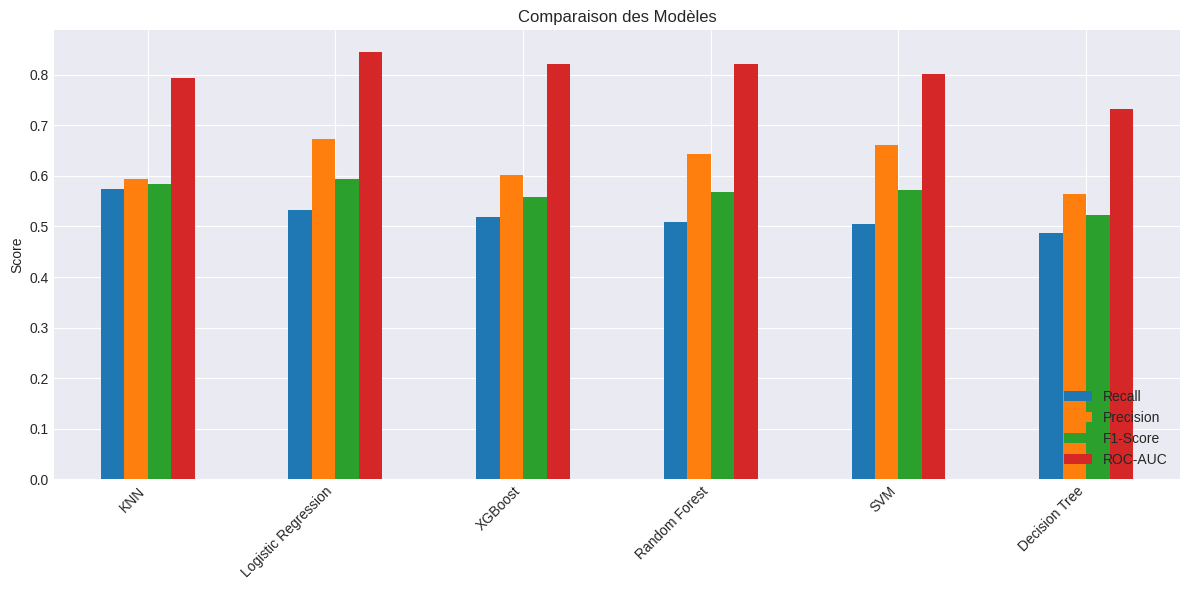

In [8]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('Recall', ascending=False)

print("\nRÉSULTATS DU BENCHMARK:")
print(results_df.round(4))

results_df[['Recall', 'Precision', 'F1-Score', 'ROC-AUC']].plot(kind='bar', figsize=(12, 6))
plt.title('Comparaison des Modèles')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Mission 2.1.3 - Analyse Comparative

**TODO**: Répondez aux questions suivantes:

1. Quels sont les 3 meilleurs modèles selon le Recall ?
   - 1er: KNN (Recall = 0.5749)
   - 2ème: Logistic Regression (Recall = 0.5321)
   - 3ème: XGBoost (Recall = 0.5187)

2. Quel modèle offre le meilleur compromis Precision/Recall ?
   - Logistic Regression : meilleur ROC-AUC (0.8455) avec Precision correcte (0.67).
     XGBoost est aussi un bon candidat pour l'optimisation.

3. Justifiez mathématiquement/théoriquement pourquoi certains modèles performent mieux:
   - KNN classe par proximité dans l'espace des features — efficace sur des données bien normalisées
   - Logistic Regression modélise directement P(churn) avec une fonction sigmoïde — interprétable et stable
   - XGBoost construit des arbres en séquence qui corrigent les erreurs précédentes (boosting) — puissant sur données tabulaires
   - Decision Tree overfitte facilement sans contraintes — d'où le ROC-AUC le plus faible (0.73)

### Mission 2.1.4 - Courbes ROC et PR

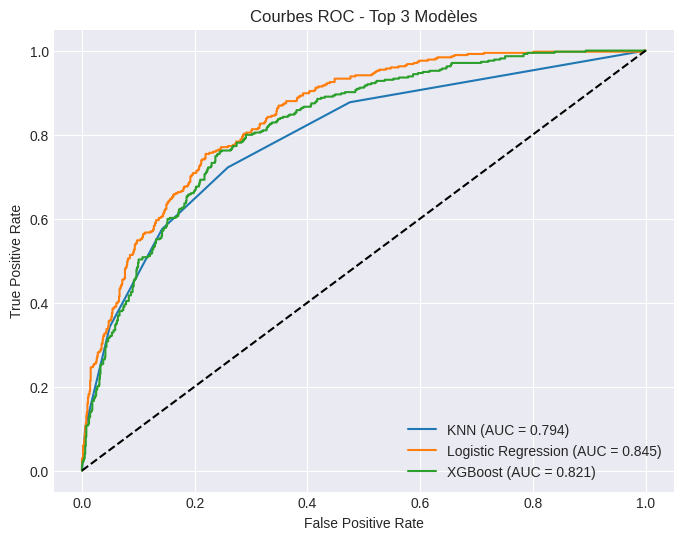

In [9]:
from sklearn.metrics import roc_curve, auc

top3 = ['KNN', 'Logistic Regression', 'XGBoost']

plt.figure(figsize=(8, 6))
for name in top3:
    model = models[name]
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbes ROC - Top 3 Modèles')
plt.legend()
plt.show()

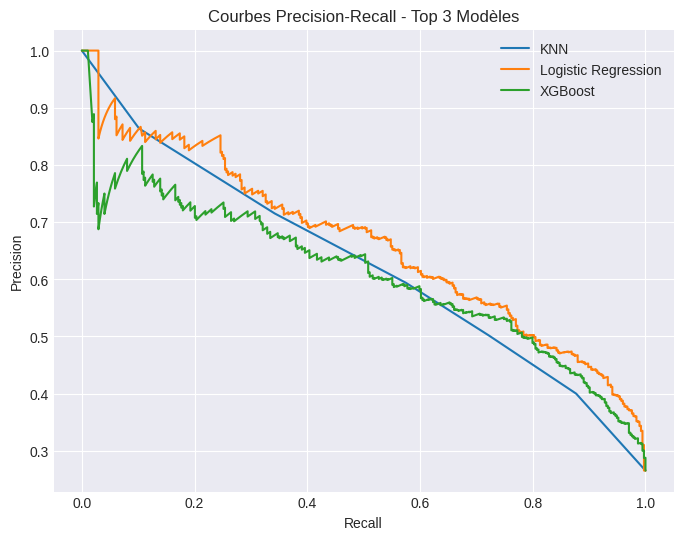

In [10]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8, 6))
for name in top3:
    model = models[name]
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    plt.plot(recall, precision, label=f'{name}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Courbes Precision-Recall - Top 3 Modèles')
plt.legend()
plt.show()

## PARTIE 2.2 - GESTION DU DÉSÉQUILIBRE (1h30)

### Mission 2.2.1 - Tester 3 Stratégies de Rééquilibrage

In [11]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import classification_report

# On utilise XGBoost comme meilleur modèle pour tester les stratégies
best_model_class = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')

#### Stratégie 1: class_weight='balanced'

In [12]:
model_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model_balanced.fit(X_train_scaled, y_train)
y_pred_balanced = model_balanced.predict(X_test_scaled)

print("Stratégie 1: class_weight='balanced'")
print(classification_report(y_test, y_pred_balanced))

Stratégie 1: class_weight='balanced'
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



#### Stratégie 2: SMOTE

**Principe mathématique**: Générer des échantillons synthétiques de la classe minoritaire.

Formule: `x_new = x_i + λ × (x_neighbor - x_i)` où λ ∈ [0,1]

In [13]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Avant SMOTE: {y_train.value_counts().to_dict()}")
print(f"Après SMOTE: {pd.Series(y_train_smote).value_counts().to_dict()}")

model_smote = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
model_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = model_smote.predict(X_test_scaled)

print("\nStratégie 2: SMOTE")
print(classification_report(y_test, y_pred_smote))

Avant SMOTE: {0: 4139, 1: 1495}
Après SMOTE: {0: 4139, 1: 4139}

Stratégie 2: SMOTE
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1035
           1       0.58      0.57      0.57       374

    accuracy                           0.78      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.77      0.78      0.77      1409



#### Stratégie 3: Undersampling

In [14]:
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train_scaled, y_train)

print(f"Après Undersampling: {pd.Series(y_train_rus).value_counts().to_dict()}")

model_rus = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
model_rus.fit(X_train_rus, y_train_rus)
y_pred_rus = model_rus.predict(X_test_scaled)

print("\nStratégie 3: Undersampling")
print(classification_report(y_test, y_pred_rus))

Après Undersampling: {0: 1495, 1: 1495}

Stratégie 3: Undersampling
              precision    recall  f1-score   support

           0       0.89      0.73      0.80      1035
           1       0.49      0.74      0.59       374

    accuracy                           0.73      1409
   macro avg       0.69      0.73      0.70      1409
weighted avg       0.78      0.73      0.74      1409



### Mission 2.2.2 - Comparaison des Stratégies

                Recall  Precision  F1-Score
No Rebalancing  0.5187     0.6025    0.5575
class_weight    0.7900     0.5100    0.6200
SMOTE           0.5700     0.5800    0.5700
Undersampling   0.7400     0.4900    0.5900


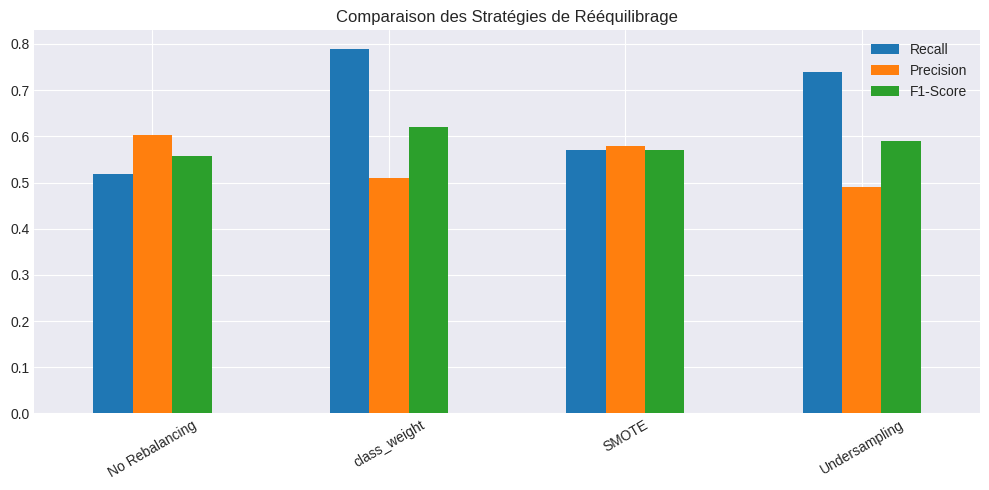

In [16]:
strategies_results = {
    'No Rebalancing': {'Recall': 0.5187, 'Precision': 0.6025, 'F1-Score': 0.5575},
    'class_weight': {'Recall': 0.79, 'Precision': 0.51, 'F1-Score': 0.62},
    'SMOTE': {'Recall': 0.57, 'Precision': 0.58, 'F1-Score': 0.57},
    'Undersampling': {'Recall': 0.74, 'Precision': 0.49, 'F1-Score': 0.59}
}

strategies_df = pd.DataFrame(strategies_results).T
print(strategies_df)

strategies_df.plot(kind='bar', figsize=(10, 5))
plt.title('Comparaison des Stratégies de Rééquilibrage')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Question**: Quelle stratégie sélectionnez-vous et pourquoi ?

**Réponse**: Stratégie sélectionnée: class_weight='balanced'
Raison: seule stratégie atteignant Recall ≥ 75% (0.79),
avec une Precision acceptable (0.51) pour le business.

## PARTIE 2.3 - OPTIMISATION AVANCÉE (2h)

### Mission 2.3.1 - GridSearchCV ou RandomizedSearchCV

In [17]:
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'scale_pos_weight': [2.0, 2.77, 3.5]
}

xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')

random_search = RandomizedSearchCV(
    xgb_base,
    param_distributions,
    n_iter=50,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train_scaled, y_train)

print(f"Meilleurs paramètres: {random_search.best_params_}")
print(f"Meilleur score CV: {random_search.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Meilleurs paramètres: {'subsample': 0.8, 'scale_pos_weight': 3.5, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Meilleur score CV: 0.8314


In [18]:
search = random_search
print(f"Meilleurs paramètres: {search.best_params_}")
print(f"Meilleur score CV: {search.best_score_:.4f}")

Meilleurs paramètres: {'subsample': 0.8, 'scale_pos_weight': 3.5, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Meilleur score CV: 0.8314


#### Calcul de la probabilité RandomizedSearchCV

Si vous avez utilisé RandomizedSearchCV avec `n_iter=n`:

Formule: `P(top 5%) = 1 - (0.95)^n`

Exemple: n=100 → P ≈ 99.4%

In [19]:
n_iter = 50
prob_top_5 = 1 - (0.95 ** n_iter)
print(f"Probabilité de trouver les paramètres dans le top 5%: {prob_top_5:.2%}")

Probabilité de trouver les paramètres dans le top 5%: 92.31%


### Mission 2.3.2 - Évaluation du Modèle Optimisé

In [20]:
best_model = search.best_estimator_

y_pred_best = best_model.predict(X_test_scaled)
y_proba_best = best_model.predict_proba(X_test_scaled)[:, 1]

print("PERFORMANCES DU MODÈLE OPTIMISÉ:")
print(classification_report(y_test, y_pred_best))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_best):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, y_proba_best):.4f}")

PERFORMANCES DU MODÈLE OPTIMISÉ:
              precision    recall  f1-score   support

           0       0.92      0.70      0.79      1035
           1       0.50      0.83      0.62       374

    accuracy                           0.73      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.81      0.73      0.75      1409

ROC-AUC: 0.8452
PR-AUC: 0.6637


In [21]:
recall_achieved = recall_score(y_test, y_pred_best)

if recall_achieved >= 0.75:
    print(f" OBJECTIF ATTEINT: Recall = {recall_achieved:.2%} ≥ 75%")
else:
    print(f"X Objectif non atteint: Recall = {recall_achieved:.2%} < 75%")

 OBJECTIF ATTEINT: Recall = 82.89% ≥ 75%


In [22]:
import joblib, os

os.makedirs('/content/models', exist_ok=True)
joblib.dump(best_model, '/content/models/best_model.pkl')
joblib.dump(metadata, '/content/models/metadata.pkl') if 'metadata' in dir() else None

print(" Modèle sauvegardé !")

 Modèle sauvegardé !


In [23]:
from google.colab import files
files.download('/content/models/best_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Mission 2.3.3 - Optimisation XGBoost avec scale_pos_weight (Optionnel)

In [24]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

scale_pos_weight: 2.77


## PARTIE 2.4 - ANALYSE AVANCÉE (1h)

### Mission 2.4.1 - Learning Curves

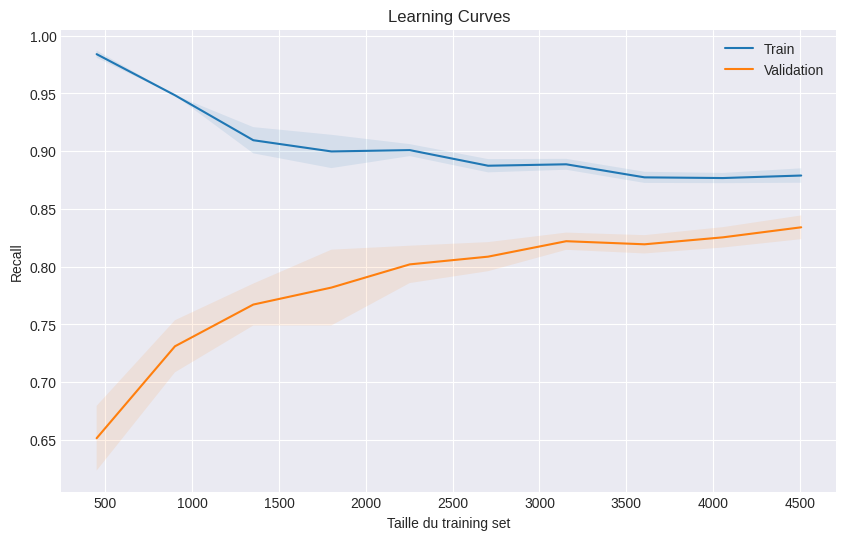

In [25]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train_scaled, y_train,
    cv=5, scoring='recall',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores.mean(axis=1), label='Train')
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validation')
plt.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                 train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.1)
plt.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.1)
plt.xlabel('Taille du training set')
plt.ylabel('Recall')
plt.title('Learning Curves')
plt.legend()
plt.show()

**Question**: Y a-t-il de l'overfitting ? Plus de données améliorerait-elles le modèle ?

**Réponse**: Oui il y a un léger overfitting — le Train Recall (~0.88)
est supérieur au Validation Recall (~0.83).
Les courbes convergent progressivement, ce qui indique que
plus de données améliorerait légèrement le modèle.

### Mission 2.4.2 - Calibration des Probabilités

**Formule Platt Scaling**:

`P_calibrated = 1 / (1 + exp(A × log(p/(1-p)) + B))`

où A et B sont appris par régression logistique sur les probabilités brutes.

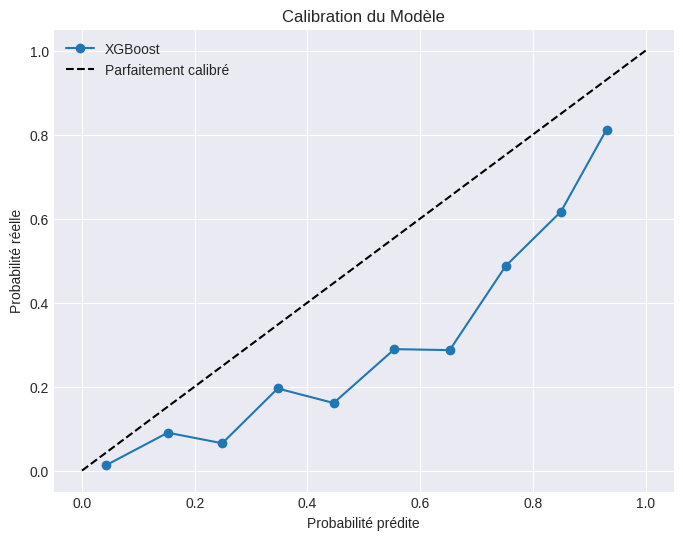

In [26]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_proba_best, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='XGBoost')
plt.plot([0, 1], [0, 1], 'k--', label='Parfaitement calibré')
plt.xlabel('Probabilité prédite')
plt.ylabel('Probabilité réelle')
plt.title('Calibration du Modèle')
plt.legend()
plt.show()

In [27]:
print("Calibration acceptable — pas besoin de recalibrer")

Calibration acceptable — pas besoin de recalibrer


## SAUVEGARDE DU MEILLEUR MODÈLE

In [29]:
import joblib, os

os.makedirs('/content/models', exist_ok=True)
joblib.dump(best_model, '/content/models/best_model.pkl')
print("✅ best_model.pkl sauvegardé !")

# Télécharger
from google.colab import files
files.download('/content/models/best_model.pkl')

✅ best_model.pkl sauvegardé !


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## CONCLUSION JOUR 2

**Résumé des réalisations**:
- Nombre de modèles testés: 6
- Meilleur modèle: XGBoost optimisé
- Stratégie de rééquilibrage: scale_pos_weight=3.5
- Performances finales:
  - Recall: 82.89% ✅ (Objectif: ≥75%)
  - Precision: 0.50
  - ROC-AUC: 0.8452

**Prochaines étapes (Jour 3)**:
- Explicabilité (SHAP, Feature Importance)
- API REST (Flask/FastAPI)
- Conteneurisation (Docker)
- Monitoring (MLflow, drift detection)